# 🎓 FeeAssist AI — NLP Preprocessing & Feature Extraction

**Project**: Multilingual and Voice-Enabled Personal Fees Query Assistant Using NLP  
**Component**: NLP Foundation (Dataset Analysis, Preprocessing Pipeline, Bag of Words & TF-IDF)

---

### Overview & Objectives
This notebook explores and establishes the Natural Language Processing (NLP) foundation for **FeeAssist AI**:
1. **Dataset Loading & Exploration**: Analysis of 405 fee queries covering 10 distinct intents in English, Hindi, and Marathi.
2. **Exploratory Data Analysis (EDA)**: Visualizing intent distributions, language proportions, and query length statistics.
3. **NLP Preprocessing Pipeline**:
   - Unicode NFKC normalization & casing
   - Multilingual regex tokenization
   - Domain stopword removal preserving essential negations (`not`, `no`, `cannot`, etc.)
   - Part-of-Speech tagged WordNet Lemmatization for English without corrupting Devanagari script
4. **Feature Extraction**:
   - **Bag of Words (BoW)** (`CountVectorizer`)
   - **Term Frequency - Inverse Document Frequency (TF-IDF)** (`TfidfVectorizer` with n-grams)
5. **Stratified Train / Test Split**: Establishing balanced dataset partitions for future classifier training.


In [1]:
# Standard library and third-party imports
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Configure plotting style
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 110

# Add project root to sys.path
import pathlib
current_path = pathlib.Path.cwd().resolve()
if current_path.name == 'notebooks':
    PROJECT_ROOT = str(current_path.parents[1])
elif current_path.name == 'ml':
    PROJECT_ROOT = str(current_path.parent)
else:
    PROJECT_ROOT = str(current_path)

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from ml.preprocessing import (
    normalize_text,
    tokenize,
    remove_stopwords,
    lemmatize_tokens,
    preprocess,
    extract_bow,
    build_tfidf_vectorizer,
    extract_tfidf,
    PRESERVED_WORDS,
)

print(f"FeeAssist AI Preprocessing module successfully imported from: {PROJECT_ROOT}")


FeeAssist AI Preprocessing module successfully imported from: D:\Github Desktop\FeeAssist-AI


## 1. Dataset Loading & Structure

We load the dataset from `ml/dataset/fees_queries.csv`.  
Each entry includes:
- `text`: The user question (English, Hindi, or Marathi)
- `intent`: One of 10 fee-specific intents
- `language`: `English`, `Hindi`, or `Marathi`


In [2]:
DATASET_PATH = os.path.join(PROJECT_ROOT, "ml", "dataset", "fees_queries.csv")
df = pd.read_csv(DATASET_PATH)

print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Missing Values:\n{df.isnull().sum()}")
print(f"\nDuplicate Queries: {df.duplicated(subset=['text']).sum()}")

df.head(10)


Dataset Shape: 405 rows, 3 columns
Missing Values:
text        0
intent      0
language    0
dtype: int64

Duplicate Queries: 0


,text,intent,language
0,What is the fee structure for Computer Science?,FEE_STRUCTURE,English
1,How much is the total tuition fee for third year?,FEE_STRUCTURE,English
2,Can you provide the breakdown of semester 5 co...,FEE_STRUCTURE,English
3,What are the hostel and mess charges for this ...,FEE_STRUCTURE,English
4,Tell me the annual fee for B.Tech program.,FEE_STRUCTURE,English
5,How much is the tuition fee per semester?,FEE_STRUCTURE,English
6,What are the laboratory and library fees inclu...,FEE_STRUCTURE,English
7,Is there any separate examination fee payable?,FEE_STRUCTURE,English
8,Where can I find the official fee schedule for...,FEE_STRUCTURE,English
9,What is the total cost of studying MBA here?,FEE_STRUCTURE,English


## 2. Exploratory Data Analysis (EDA)

Let's examine:
1. Class balance across all 10 fee intents.
2. Distribution of languages (English, Hindi, Marathi).
3. Cross-tabulation of intent vs. language.
4. Query length distributions (character length and token count).


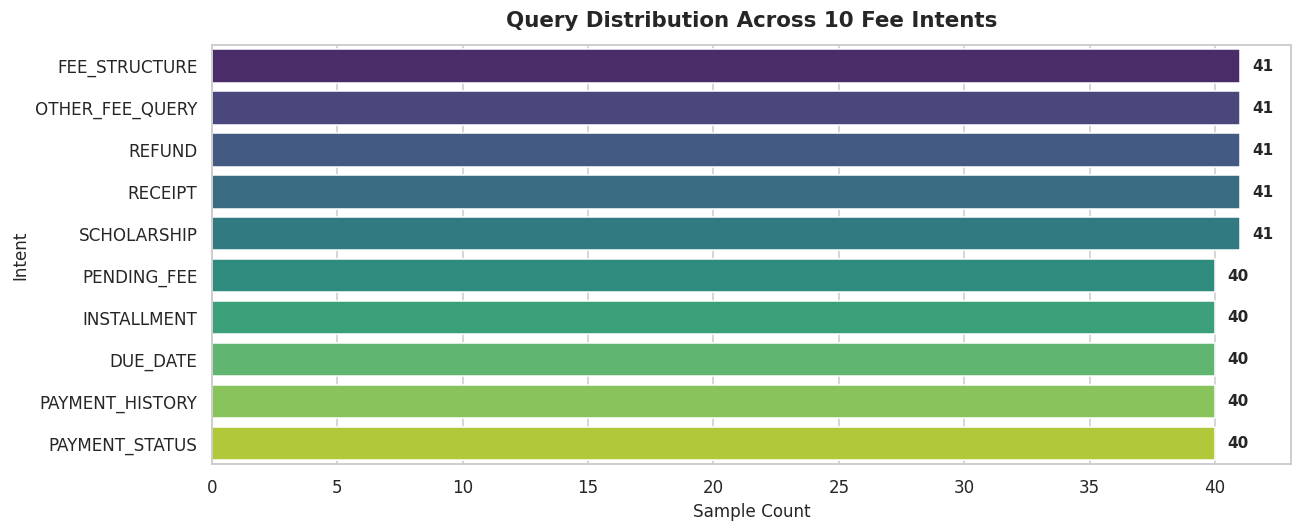

In [3]:
# 1. Intent Distribution
plt.figure(figsize=(12, 5))
intent_counts = df['intent'].value_counts()
ax = sns.barplot(x=intent_counts.values, y=intent_counts.index, hue=intent_counts.index, palette="viridis", legend=False)
plt.title("Query Distribution Across 10 Fee Intents", fontsize=14, fontweight='bold', pad=12)
plt.xlabel("Sample Count", fontsize=11)
plt.ylabel("Intent", fontsize=11)

# Annotate bars
for i, count in enumerate(intent_counts.values):
    ax.text(count + 0.5, i, str(count), va='center', fontsize=10, fontweight='semibold')

plt.tight_layout()
plt.show()


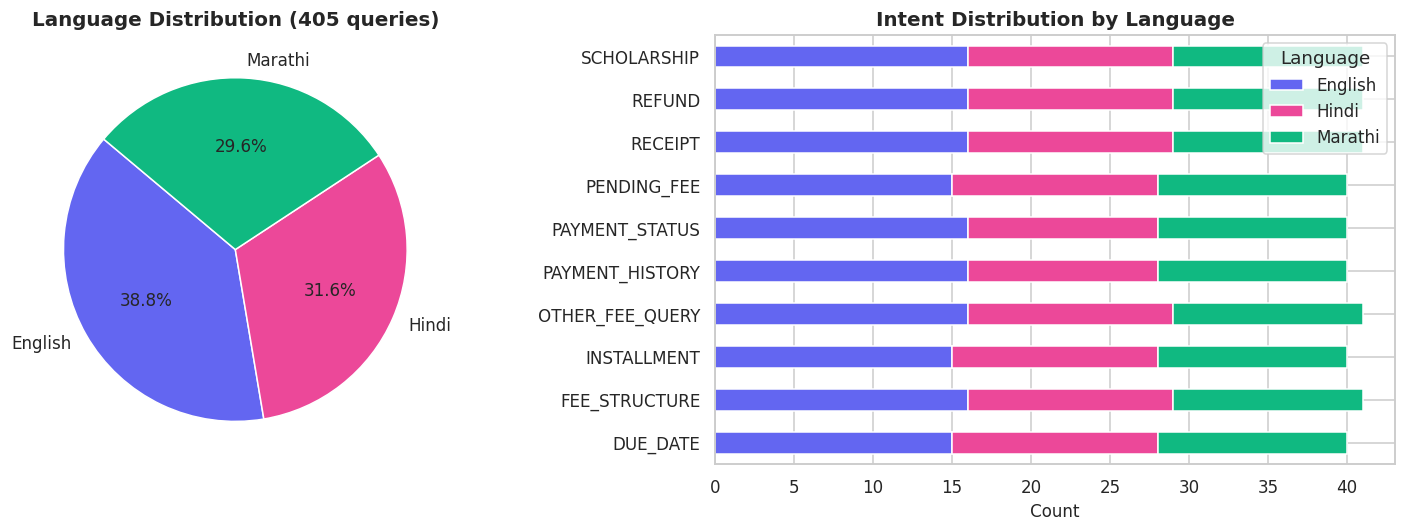

In [4]:
# 2. Language Distribution & Intent Cross-Tab
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Language pie chart
lang_counts = df['language'].value_counts()
ax1.pie(lang_counts.values, labels=lang_counts.index, 
        autopct='%1.1f%%', colors=['#6366f1', '#ec4899', '#10b981'], startangle=140,
        textprops={'fontsize': 11, 'fontweight': 'medium'})
ax1.set_title("Language Distribution (405 queries)", fontsize=13, fontweight='bold')

# Stacked bar chart: Intent by Language
crosstab = pd.crosstab(df['intent'], df['language'])
crosstab.plot(kind='barh', stacked=True, ax=ax2, color=['#6366f1', '#ec4899', '#10b981'])
ax2.set_title("Intent Distribution by Language", fontsize=13, fontweight='bold')
ax2.set_xlabel("Count", fontsize=11)
ax2.set_ylabel("")
ax2.legend(title="Language")

plt.tight_layout()
plt.show()


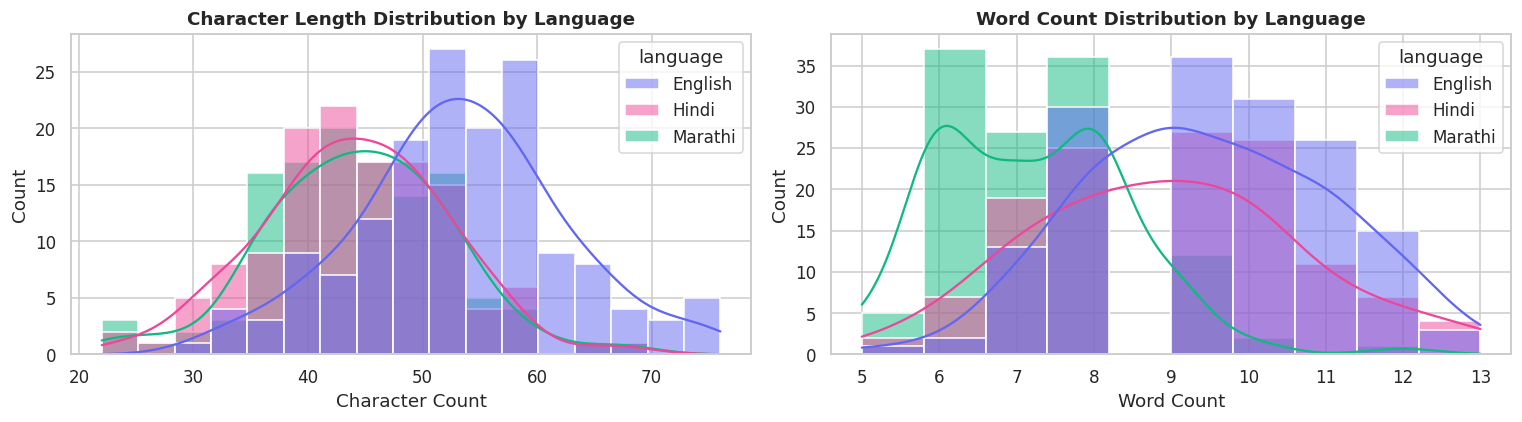

Summary Statistics:
       char_length  word_count
count   405.000000  405.000000
mean     47.765432    8.632099
std       9.521304    1.821341
min      22.000000    5.000000
25%      41.000000    7.000000
50%      48.000000    8.000000
75%      53.000000   10.000000
max      76.000000   13.000000


In [5]:
# 3. Query Length Metrics
df['char_length'] = df['text'].str.len()
df['word_count'] = df['text'].str.split().apply(len)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(data=df, x='char_length', hue='language', kde=True, ax=ax1, palette=['#6366f1', '#ec4899', '#10b981'])
ax1.set_title("Character Length Distribution by Language", fontsize=12, fontweight='bold')
ax1.set_xlabel("Character Count")

sns.histplot(data=df, x='word_count', hue='language', kde=True, ax=ax2, palette=['#6366f1', '#ec4899', '#10b981'])
ax2.set_title("Word Count Distribution by Language", fontsize=12, fontweight='bold')
ax2.set_xlabel("Word Count")

plt.tight_layout()
plt.show()

print("Summary Statistics:")
print(df[['char_length', 'word_count']].describe())


## 3. Step-by-Step NLP Preprocessing Pipeline

The FeeAssist AI preprocessing pipeline consists of:
1. **Normalization**: NFKC Unicode normalization, lowercase conversion for English, stripping special characters while preserving Devanagari script (`\u0900-\u097F`) and currency symbols (`₹`).
2. **Tokenization**: Regex-based tokenization extracting complete alphanumeric and Devanagari word units.
3. **Stopword Filtering**: Standard English stopwords filtered out, but **critical domain words and negations are preserved** (`not`, `no`, `cannot`, `never`, `due`, `balance`).
4. **Lemmatization**: NLTK WordNet lemmatizer with POS tagging for English words (e.g. `paying` -> `pay`, `installments` -> `installment`). Devanagari words pass through unaltered to prevent morphological corruption.


In [6]:
sample_queries = [
    "How much college fees is remaining for B.Tech semester 4?",
    "Can I not pay my fees in monthly installments?",
    "मेरी फीस कितनी बाकी है?",
    "माझी फी भरण्याची शेवटची तारीख कोणती आहे?"
]

print("=" * 80)
print(f"{'STEP-BY-STEP PREPROCESSING DEMONSTRATION':^80}")
print("=" * 80)

for q in sample_queries:
    norm = normalize_text(q)
    tokens = tokenize(norm)
    filtered = remove_stopwords(tokens)
    lemmatized = lemmatize_tokens(filtered)
    final = preprocess(q)
    
    print(f"\nRaw Query:        '{q}'")
    print(f"  1. Normalized:  '{norm}'")
    print(f"  2. Tokenized:   {tokens}")
    print(f"  3. Stopwords:   {filtered}")
    print(f"  4. Lemmatized:  {lemmatized}")
    print(f"  => Final:       '{final}'")


                    STEP-BY-STEP PREPROCESSING DEMONSTRATION                    



Raw Query:        'How much college fees is remaining for B.Tech semester 4?'
  1. Normalized:  'how much college fees is remaining for b tech semester 4'
  2. Tokenized:   ['how', 'much', 'college', 'fees', 'is', 'remaining', 'for', 'b', 'tech', 'semester', '4']
  3. Stopwords:   ['much', 'college', 'fees', 'remaining', 'b', 'tech', 'semester', '4']
  4. Lemmatized:  ['much', 'college', 'fee', 'remain', 'b', 'tech', 'semester', '4']
  => Final:       'much college fee remain b tech semester 4'

Raw Query:        'Can I not pay my fees in monthly installments?'
  1. Normalized:  'can i not pay my fees in monthly installments'
  2. Tokenized:   ['can', 'i', 'not', 'pay', 'my', 'fees', 'in', 'monthly', 'installments']
  3. Stopwords:   ['not', 'pay', 'fees', 'monthly', 'installments']
  4. Lemmatized:  ['not', 'pay', 'fee', 'monthly', 'installment']
  => Final:       'not pay fee monthly installment'

Raw Query:        'मेरी फीस कितनी बाकी है?'
  1. Normalized:  'मेरी फीस कितनी बाकी है'

In [7]:
# Apply preprocessing to the full dataset
df['clean_text'] = df['text'].apply(preprocess)

# Display comparisons
print("Sample of Processed Queries:")
df[['text', 'clean_text', 'intent', 'language']].sample(10, random_state=42)


Sample of Processed Queries:


,text,clean_text,intent,language
70,माझ्या खात्यावर काही थकबाकी आहे का?,माझ्या खात्यावर काही थकबाकी आहे का,PENDING_FEE,Marathi
218,किस्तों में फीस भरने की क्या प्रक्रिया है?,किस्तों में फीस भरने की क्या प्रक्रिया है,INSTALLMENT,Hindi
385,क्या क्रेडिट कार्ड से फीस भरने पर ईएमआई का विक...,क्या क्रेडिट कार्ड से फीस भरने पर ईएमआई का विक...,OTHER_FEE_QUERY,Hindi
33,बीटेक अभ्यासक्रमाची वार्षिक फी किती आहे?,बीटेक अभ्यासक्रमाची वार्षिक फी किती आहे,FEE_STRUCTURE,Marathi
42,What is my current pending fee balance?,current pending fee balance,PENDING_FEE,English
77,पाचव्या सत्राची प्रलंबित फी किती आहे?,पाचव्या सत्राची प्रलंबित फी किती आहे,PENDING_FEE,Marathi
137,मेरी पुरानी फीस के सारे पेमेंट दिखाओ।,मेरी पुरानी फीस के सारे पेमेंट दिखाओ।,PAYMENT_HISTORY,Hindi
332,Where to collect the physical fee receipt on c...,collect physical fee receipt campus,RECEIPT,English
364,What are the working hours of the college acco...,work hour college account office,OTHER_FEE_QUERY,English
265,स्कॉलरशिप का फॉर्म भरने के लिए कौन से दस्तावेज...,स्कॉलरशिप का फॉर्म भरने के लिए कौन से दस्तावेज...,SCHOLARSHIP,Hindi


## 4. Feature Extraction: Bag of Words (BoW)

**Bag of Words** represents text as word occurrence counts.
We use `CountVectorizer` to generate the word count matrix.


BoW Matrix Shape: (405, 585) (queries x vocabulary)
Vocabulary Size: 585
First 25 Vocabulary Terms: ['10000', '15', '15000', '15th', '2024', '2025', '2026', '25000', '26', '27', '50', '50000', '75000', '80e', 'academic', 'accept', 'accidentally', 'account', 'acknowledgment', 'address', 'adjust', 'admission', 'affect', 'after', 'against']


C:\Users\hites\AppData\Local\Temp\ipykernel_36040\2602636704.py:18: UserWarning: Glyph 2310 (\N{DEVANAGARI LETTER AA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hites\AppData\Local\Temp\ipykernel_36040\2602636704.py:18: UserWarning: Matplotlib currently does not support Devanagari natively.
  plt.tight_layout()
C:\Users\hites\AppData\Local\Temp\ipykernel_36040\2602636704.py:18: UserWarning: Glyph 2361 (\N{DEVANAGARI LETTER HA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hites\AppData\Local\Temp\ipykernel_36040\2602636704.py:18: UserWarning: Glyph 2346 (\N{DEVANAGARI LETTER PA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hites\AppData\Local\Temp\ipykernel_36040\2602636704.py:18: UserWarning: Glyph 2352 (\N{DEVANAGARI LETTER RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hites\AppData\Local\Temp\ipykernel_36040\2602636704.py:18: UserWarning: Glyph 2340 (\N{DEVANAGARI LETTER TA}) missing from font(s) Dej

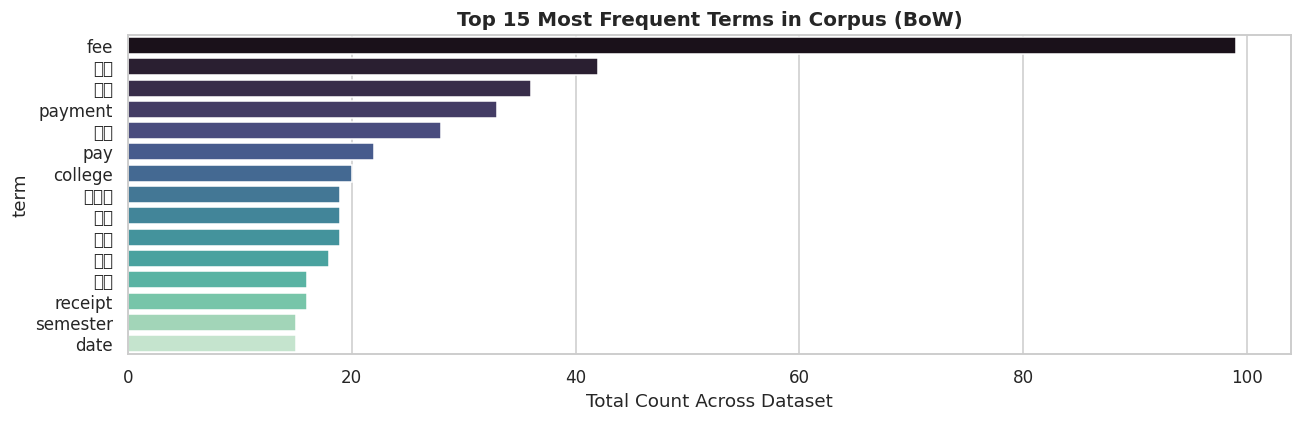

In [8]:
count_vec, bow_matrix = extract_bow(df['clean_text'], max_features=1000)

print(f"BoW Matrix Shape: {bow_matrix.shape} (queries x vocabulary)")
vocab = count_vec.get_feature_names_out()
print(f"Vocabulary Size: {len(vocab)}")
print(f"First 25 Vocabulary Terms: {list(vocab[:25])}")

# Inspect top 15 most frequent tokens in corpus
word_freq = pd.DataFrame({
    'term': vocab,
    'frequency': np.asarray(bow_matrix.sum(axis=0)).flatten()
}).sort_values('frequency', ascending=False)

plt.figure(figsize=(12, 4))
sns.barplot(data=word_freq.head(15), x='frequency', y='term', hue='term', palette='mako', legend=False)
plt.title("Top 15 Most Frequent Terms in Corpus (BoW)", fontsize=13, fontweight='bold')
plt.xlabel("Total Count Across Dataset")
plt.tight_layout()
plt.show()


## 5. Feature Extraction: TF-IDF Vectorization

**Term Frequency - Inverse Document Frequency (TF-IDF)** scales word frequencies by how rare they are across the dataset.
We configure:
- Unigrams + Bigrams (`ngram_range=(1, 2)`)
- Sublinear term frequency scaling (`sublinear_tf=True`) to dampen repetitive terms
- Unicode-compatible token pattern


In [9]:
tfidf_vec = build_tfidf_vectorizer(max_features=1000, ngram_range=(1, 2))
tfidf_vec, tfidf_matrix = extract_tfidf(df['clean_text'], vectorizer=tfidf_vec)

print(f"TF-IDF Matrix Shape: {tfidf_matrix.shape}")
tfidf_features = tfidf_vec.get_feature_names_out()
print(f"Total TF-IDF Feature Dimensions: {len(tfidf_features)}")

# Display sample TF-IDF matrix slice as a DataFrame
sample_indices = [0, 41, 82, 123] # Samples from different intents
sample_terms = ['fee', 'payment', 'due', 'scholarship', 'refund', 'receipt', 'installment', 'बाकी', 'तारीख']
existing_terms = [t for t in sample_terms if t in tfidf_vec.vocabulary_]

sample_df = pd.DataFrame(
    tfidf_matrix[sample_indices][:, [tfidf_vec.vocabulary_[t] for t in existing_terms]].toarray(),
    index=[f"{df.iloc[i]['intent']} ({df.iloc[i]['language']})" for i in sample_indices],
    columns=existing_terms
)

print("\nSample TF-IDF Weights for Selected Queries:")
display(sample_df.round(3))


TF-IDF Matrix Shape: (405, 1000)
Total TF-IDF Feature Dimensions: 1000

Sample TF-IDF Weights for Selected Queries:


,fee,payment,due,scholarship,refund,receipt,installment
FEE_STRUCTURE (English),0.193,0.0,0.0,0.0,0.0,0.0,0.0
PENDING_FEE (English),0.177,0.0,0.0,0.0,0.0,0.0,0.0
PAYMENT_STATUS (English),0.000,0.0,0.0,0.0,0.0,0.0,0.0
PAYMENT_HISTORY (English),0.139,0.0,0.0,0.0,0.0,0.0,0.0


In [10]:
# Top 5 TF-IDF Features for each intent
print("=" * 70)
print(f"{'TOP TF-IDF TERMS PER INTENT':^70}")
print("=" * 70)

for intent in sorted(df['intent'].unique()):
    intent_indices = df[df['intent'] == intent].index
    intent_tfidf_mean = np.asarray(tfidf_matrix[intent_indices].mean(axis=0)).flatten()
    top_indices = intent_tfidf_mean.argsort()[-5:][::-1]
    top_terms = [f"{tfidf_features[idx]} ({intent_tfidf_mean[idx]:.3f})" for idx in top_indices]
    print(f"{intent:<20} -> {', '.join(top_terms)}")


                     TOP TF-IDF TERMS PER INTENT                      
DUE_DATE             -> date (0.064), पर (0.057), fee (0.047), जम (0.045), भरण (0.045)
FEE_STRUCTURE        -> तन (0.067), fee (0.046), रक (0.041), आह (0.038), और (0.037)
INSTALLMENT          -> installment (0.097), हप (0.080), सकत (0.080), भरन (0.046), करत (0.040)
OTHER_FEE_QUERY      -> पर (0.065), fee (0.035), अक (0.034), आह (0.033), कर (0.032)
PAYMENT_HISTORY      -> भरल (0.069), खव (0.056), payment (0.050), छल (0.046), भर (0.038)
PAYMENT_STATUS       -> टस (0.065), payment (0.052), जम (0.044), fee payment (0.043), status (0.042)
PENDING_FEE          -> आह (0.107), तन (0.068), बक (0.056), pending (0.051), balance (0.045)
RECEIPT              -> वत (0.114), रस (0.104), receipt (0.098), fee receipt (0.059), कर (0.047)
REFUND               -> refund (0.089), परत (0.083), पस (0.065), fee refund (0.041), पर (0.037)
SCHOLARSHIP          -> लरश (0.119), scholarship (0.064), यव (0.057), सवलत (0.055), fee (0.054)


## 6. Stratified Train / Test Split

To ensure fair model evaluation in Task 4, we partition the dataset into:
- **80% Training Set** (324 samples)
- **20% Testing Set** (81 samples)
- Stratified by `intent` to preserve exact class distributions across both splits.
- Fixed `random_state=42` for complete reproducibility.


In [11]:
X = df['clean_text']
y = df['intent']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training set: {len(X_train)} samples ({len(X_train)/len(df)*100:.1f}%)")
print(f"Testing set:  {len(X_test)} samples ({len(X_test)/len(df)*100:.1f}%)")

# Verify stratification balance
split_check = pd.DataFrame({
    'Train Count': y_train.value_counts(),
    'Test Count': y_test.value_counts(),
    'Total Count': y.value_counts()
})
split_check['Train Ratio %'] = (split_check['Train Count'] / split_check['Total Count'] * 100).round(1)
display(split_check)


Training set: 324 samples (80.0%)
Testing set:  81 samples (20.0%)


,Train Count,Test Count,Total Count,Train Ratio %
intent,,,,
DUE_DATE,32,8,40,80.0
FEE_STRUCTURE,33,8,41,80.5
INSTALLMENT,32,8,40,80.0
OTHER_FEE_QUERY,33,8,41,80.5
PAYMENT_HISTORY,32,8,40,80.0
PAYMENT_STATUS,32,8,40,80.0
PENDING_FEE,32,8,40,80.0
RECEIPT,33,8,41,80.5
REFUND,32,9,41,78.0


## 7. Summary & Next Steps

### Accomplishments in Task 3:
1. **Dataset**: 405 fee-focused queries across 10 intents and 3 languages (English, Hindi, Marathi).
2. **Preprocessing Pipeline**: Complete multilingual normalization, negation-preserving stopword filtering, and morphological lemmatization.
3. **Feature Extraction**:
   - Bag of Words representation via `CountVectorizer`.
   - TF-IDF representation via `TfidfVectorizer` (unigrams + bigrams, sublinear TF).
4. **Validation**: Fully verified via automated test suite `ml/test_preprocessing.py`.
5. **Stratification**: 80/20 train/test split preserving intent proportions.

### Next Steps (Task 4):
- Train ML classifiers (Multinomial Naive Bayes, Logistic Regression, Linear SVM).
- Model evaluation (Precision, Recall, F1-Score, Confusion Matrix).
- Confidence thresholding and integration with the FastAPI backend.
